# Apple Segmentation with U-Net (ResNet-34)

**Goal:** Train U-Net to segment apples from background in cropped fruit images.
**Input:** RGB fruit crop (256x256)
**Output:** Binary mask (apple=1, background=0)
**Architecture:** U-Net with ResNet-34 encoder
**Loss:** BCE + Dice
**Runtime:** GPU (T4)

## 1. Setup & Install

In [ ]:
!pip install -q segmentation-models-pytorch albumentations roboflow
import os
os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 37.9 MB/s eta 0:00:00


## 2. Download Apple Dataset from Roboflow (with segmentation)

In [1]:
from roboflow import Roboflow
from pathlib import Path
import shutil

API_KEY = "evNnmWyUlNy3mu4YXnhM"
rf = Roboflow(api_key=API_KEY)

# Download COCO JSON format (has polygon segmentation masks)
print("=== Downloading l61l/apple-desti (COCO format) ===")
project = rf.workspace("l61l").project("apple-desti")
dataset = project.versions()[0].download("coco")

DATASET_DIR = Path(dataset.location)
print(f"Dataset: {DATASET_DIR}")

# Also get images
print("\n=== Downloading images (YOLO format for images) ===")
yolo_ds = project.versions()[0].download("yolov8")
YOLO_DIR = Path(yolo_ds.location)
print(f"YOLO dir: {YOLO_DIR}")

=== Downloading l61l/apple-desti (COCO format) ===
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to apple-14 in coco:: 100%|██████████| 1278/1278 [00:00<00:00, 4776.95it/s]


Dataset: /content/apple-14

=== Downloading images (YOLO format for images) ===
YOLO dir: /content/apple-14


## 3. Parse COCO Annotations & Generate Binary Masks

In [26]:
import shutil
from pathlib import Path
import json
import cv2
import numpy as np
from collections import defaultdict

# === (SAM already installed and loaded from previous cell) ===

COCO_DIR = Path("/content/apple-coco")

# Load COCO annotations
coco_jsons = sorted(COCO_DIR.rglob("*_annotations.coco.json"))
all_coco_images = {}
all_coco_anns = []
for cjson in coco_jsons:
    with open(cjson) as f:
        coco = json.load(f)
    for img in coco.get('images', []):
        all_coco_images[img['id']] = img
    for ann in coco.get('annotations', []):
        all_coco_anns.append(ann)

anns_by_img = defaultdict(list)
for ann in all_coco_anns:
    anns_by_img[ann['image_id']].append(ann)

print(f"Images: {len(all_coco_images)} | Annotations: {len(all_coco_anns)}")

# Find images on disk
disk_images = {}
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    for p in COCO_DIR.rglob(ext):
        disk_images[p.name] = p
        disk_images[p.stem] = p

# Output dir
OUT_DIR = Path("/content/datasets/apple_masks")
shutil.rmtree(OUT_DIR, ignore_errors=True)
(OUT_DIR / "images").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "masks").mkdir(parents=True, exist_ok=True)

count = 0

for img_id, img in all_coco_images.items():
    fname = img['file_name']
    img_path = disk_images.get(fname) or disk_images.get(Path(fname).stem)
    if img_path is None:
        continue

    image = cv2.imread(str(img_path))
    if image is None:
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    # Collect bounding boxes
    bboxes = []
    for ann in anns_by_img.get(img_id, []):
        bbox = ann.get('bbox')
        if bbox and len(bbox) == 4:
            x, y, bw, bh = bbox
            bboxes.append([x, y, x + bw, y + bh])

    if not bboxes:
        continue

    # SAM: set image once
    predictor.set_image(image_rgb)

    # Predict EACH box individually and OR the masks
    combined = np.zeros((h, w), dtype=np.uint8)
    for box in bboxes:
        masks, scores, logits = predictor.predict(
            point_coords=None,
            point_labels=None,
            box=np.array(box),  # <-- Single box, not array of boxes
            multimask_output=False,
        )
        combined[masks[0].astype(bool)] = 255

    # Save
    out_name = Path(fname).stem + ".png"
    cv2.imwrite(str(OUT_DIR / "images" / out_name), image)
    cv2.imwrite(str(OUT_DIR / "masks" / out_name), combined)
    count += 1

    if count % 100 == 0:
        print(f"  Processed {count} images...")

print(f"\n{'='*50}")
print(f"TOTAL: {count} images with SAM masks")
print(f"{'='*50}")

Images: 1040 | Annotations: 6031
  Processed 100 images...
  Processed 200 images...
  Processed 300 images...
  Processed 400 images...
  Processed 500 images...
  Processed 600 images...
  Processed 700 images...
  Processed 800 images...
  Processed 900 images...
  Processed 1000 images...

TOTAL: 1040 images with SAM masks


## 4. Train/Val Split

In [27]:
import random
import shutil

random.seed(42)

all_imgs = sorted((OUT_DIR / "images").glob("*.png"))
random.shuffle(all_imgs)

split = int(0.85 * len(all_imgs))
train_imgs = all_imgs[:split]
val_imgs = all_imgs[split:]

for split_name, imgs in [("train", train_imgs), ("val", val_imgs)]:
    (OUT_DIR / split_name / "images").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / split_name / "masks").mkdir(parents=True, exist_ok=True)
    for img_path in imgs:
        mask_path = OUT_DIR / "masks" / img_path.name
        shutil.move(str(img_path), str(OUT_DIR / split_name / "images" / img_path.name))
        shutil.move(str(mask_path), str(OUT_DIR / split_name / "masks" / img_path.name))

# Clean up empty dirs
shutil.rmtree(OUT_DIR / "images", ignore_errors=True)
shutil.rmtree(OUT_DIR / "masks", ignore_errors=True)

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

Train: 884 | Val: 156


## 5. U-Net Dataset & DataLoader

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class AppleSegDataset(Dataset):
    def __init__(self, root, split, transform):
        self.root = Path(root) / split
        self.imgs = sorted((self.root / "images").glob("*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        mask_path = self.root / "masks" / img_path.name

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        transformed = self.transform(image=img, mask=mask)
        img_t = transformed["image"]
        mask_t = transformed["mask"].float() / 255.0
        mask_t = mask_t.unsqueeze(0)  # (1, H, W)

        return img_t, mask_t

train_ds = AppleSegDataset(OUT_DIR, "train", train_transform)
val_ds = AppleSegDataset(OUT_DIR, "val", val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 884 | Val: 156


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
Argument(s) 'var_limit' are not valid for transform GaussNoise


## 6. Train U-Net

In [29]:
import segmentation_models_pytorch as smp
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
).to(DEVICE)

# BCE + Dice loss
bce = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary", from_logits=True)

def criterion(pred, target):
    return bce(pred, target) + dice(pred, target)

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

EPOCHS = 50
best_loss = float('inf')
save_dir = Path("/content/runs/apple_segment")
save_dir.mkdir(parents=True, exist_ok=True)

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Val
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), save_dir / "best_unet.pth")
        print(f"  -> Saved best model (val_loss={val_loss:.4f})")

    # Early stopping (patience=10)
    if epoch > 10 and val_loss > best_loss * 1.05:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nTraining complete. Best val_loss: {best_loss:.4f}")
print(f"Model saved to: {save_dir / 'best_unet.pth'}")

Device: cuda


Epoch 1/50 [Val]: 100%|██████████| 10/10 [00:02<00:00,  3.87it/s]


Epoch 1: train_loss=0.5858, val_loss=0.5992
  -> Saved best model (val_loss=0.5992)


Epoch 2/50 [Val]: 100%|██████████| 10/10 [00:02<00:00,  4.89it/s]


Epoch 2: train_loss=0.4775, val_loss=0.4610
  -> Saved best model (val_loss=0.4610)


...

Epoch 12: train_loss=0.3402, val_loss=0.3294


Epoch 13/50 [Val]: 100%|██████████| 10/10 [00:02<00:00,  4.75it/s]


Epoch 13: train_loss=0.3370, val_loss=0.3377


Epoch 14/50 [Val]: 100%|██████████| 10/10 [00:01<00:00,  5.16it/s]

Epoch 14: train_loss=0.3300, val_loss=0.3671
Early stopping at epoch 14

Training complete. Best val_loss: 0.3237
Model saved to: /content/runs/apple_segment/best_unet.pth


## 7. Visualize Results

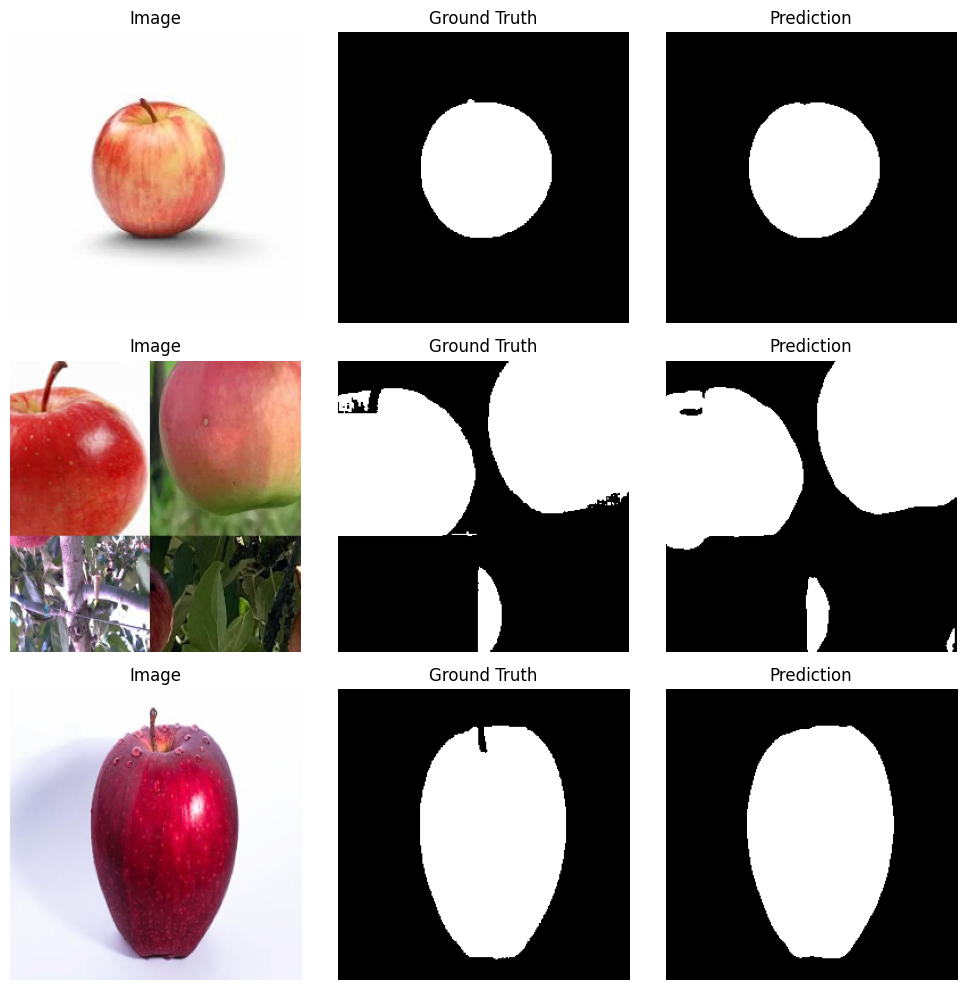

In [30]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(save_dir / "best_unet.pth"))
model.eval()

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, (img, mask) in enumerate(val_ds):
    if i >= 3:
        break
    img_b = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_b))[0, 0].cpu().numpy()

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask[0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred > 0.5, cmap="gray")
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 8. Export & Download

In [31]:
from google.colab import files

files.download(str(save_dir / "best_unet.pth"))
print("Download best_unet.pth and rename to unet_fruit.pth")
print("Place in: pomegranate_models/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download best_unet.pth and rename to unet_fruit.pth
Place in: pomegranate_models/
